# Unthresholded Perceptron & Delta Rule
This notebook implements a linear unit using both Batch Gradient Descent and Stochastic Gradient Descent (SGD) to minimize the squared-error cost.

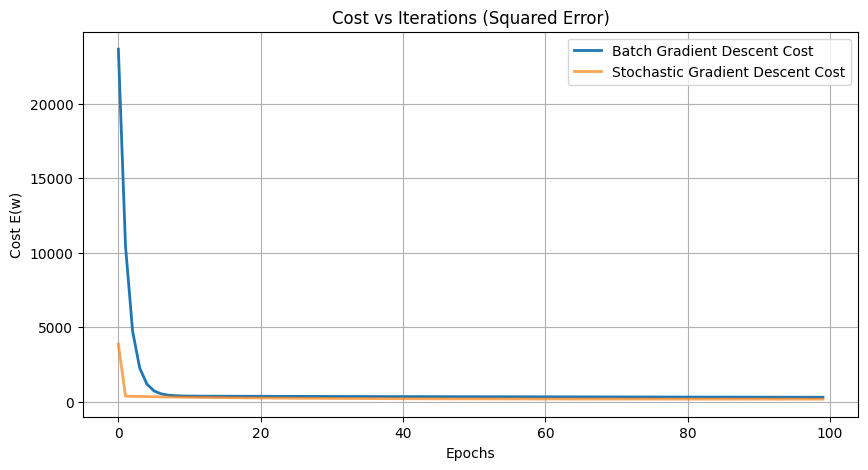

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class UnthresholdedPerceptron:
    def __init__(self, learning_rate=0.01, epochs=50, mode='batch'):
        self.eta = learning_rate
        self.epochs = epochs
        self.mode = mode
        self.w = None
        self.cost_history = []

    def fit(self, X, y):
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        self.w = np.zeros(X_bias.shape[1])
        N = X.shape[0]

        for epoch in range(self.epochs):
            if self.mode == 'batch':
                # Batch Gradient Descent
                outputs = np.dot(X_bias, self.w)
                errors = y - outputs

                # Cost: 1/2 * sum(t - o)^2
                cost = 0.5 * np.sum(errors ** 2)

                # Gradient of E
                gradient = -np.dot(X_bias.T, errors)
                self.w -= self.eta * gradient

            elif self.mode == 'stochastic':
                # Stochastic / Incremental Gradient Descent
                indices = np.random.permutation(N)
                cost = 0
                for i in indices:
                    xi = X_bias[i]
                    target = y[i]
                    output = np.dot(xi, self.w)
                    error = target - output
                    cost += 0.5 * (error ** 2)

                    gradient = -error * xi
                    self.w -= self.eta * gradient

            self.cost_history.append(cost)

# Toy Dataset for regression
np.random.seed(42)
X_data = np.linspace(0, 10, 100).reshape(-1, 1)
y_data = 3 * X_data.flatten() + 5 + np.random.randn(100) * 2

# Train Batch GD
model_batch = UnthresholdedPerceptron(learning_rate=0.0001, epochs=100, mode='batch')
model_batch.fit(X_data, y_data)

# Train Stochastic GD
model_sgd = UnthresholdedPerceptron(learning_rate=0.001, epochs=100, mode='stochastic')
model_sgd.fit(X_data, y_data)

# Plot Cost vs Iterations
plt.figure(figsize=(10, 5))
plt.plot(model_batch.cost_history, label='Batch Gradient Descent Cost', lw=2)
plt.plot(model_sgd.cost_history, label='Stochastic Gradient Descent Cost', lw=2, alpha=0.7)
plt.title('Cost vs Iterations (Squared Error)')
plt.xlabel('Epochs')
plt.ylabel('Cost E(w)')
plt.legend()
plt.grid(True)
plt.show()